# Decision Tree

## Overview
A Decision Tree is a non-parametric, tree-structured model that splits data into branches based on feature thresholds, ultimately leading to leaf nodes that represent a prediction. It works for both **classification** and **regression**.

### Splitting Criteria (Classification):
**Gini Impurity:**
$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

**Entropy:**
$$Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

**Information Gain:**
$$IG = Entropy(\text{parent}) - \sum_{k} \frac{n_k}{n} \cdot Entropy(\text{child}_k)$$

### Splitting Criterion (Regression):
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \bar{y})^2$$

At each node, the tree picks the feature and threshold that **minimizes impurity** (or MSE) the most.

---
### Topics Covered
1. Gini vs Entropy intuition
2. Classification tree — synthetic dataset
3. Tree structure visualization
4. Decision boundary
5. Overfitting — effect of max_depth
6. Pruning with ccp_alpha (Cost Complexity Pruning)
7. Feature importance
8. Regression tree
9. Real-world offline-safe dataset
10. Model evaluation


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay, mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.datasets import make_classification, make_regression

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Gini vs Entropy — Intuition

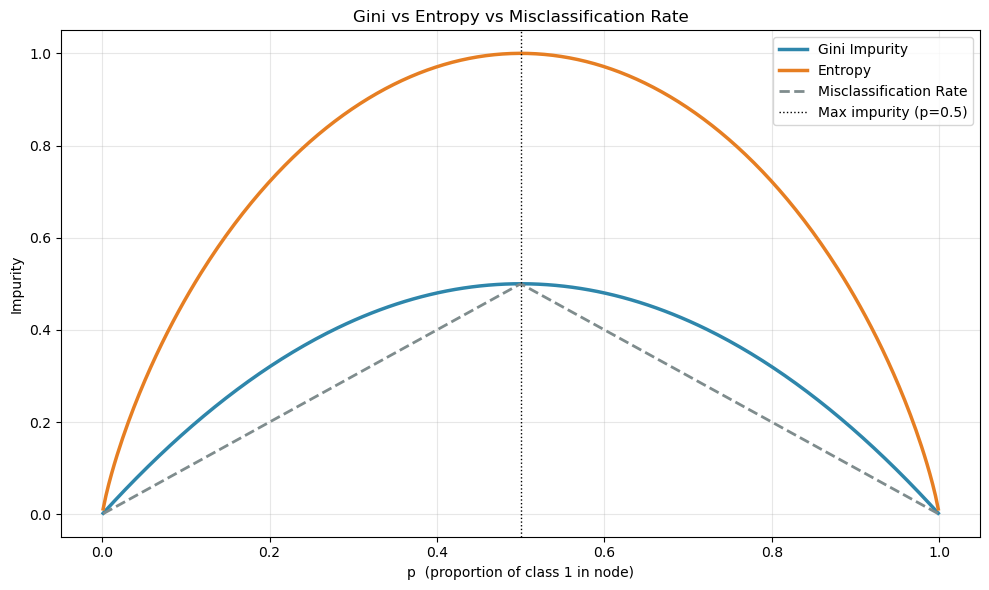

Both Gini and Entropy peak at p=0.5 (maximum disorder)
and are zero at p=0 or p=1 (pure node — only one class present).

Gini(0.5)    = 0.5000
Entropy(0.5) = 1.0000


In [2]:
def gini(p):
    return 1 - p**2 - (1-p)**2

def entropy(p):
    p = np.clip(p, 1e-12, 1-1e-12)
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

def misclassification(p):
    return 1 - np.maximum(p, 1-p)

p_values = np.linspace(0.001, 0.999, 300)

plt.figure(figsize=(10, 6))
plt.plot(p_values, gini(p_values), color=COLORS['primary'],
         linewidth=2.5, label='Gini Impurity')
plt.plot(p_values, entropy(p_values), color=COLORS['secondary'],
         linewidth=2.5, label='Entropy')
plt.plot(p_values, misclassification(p_values), color=COLORS['neutral'],
         linewidth=2, linestyle='--', label='Misclassification Rate')
plt.axvline(0.5, color='black', linestyle=':', linewidth=1, label='Max impurity (p=0.5)')
plt.xlabel('p  (proportion of class 1 in node)')
plt.ylabel('Impurity')
plt.title('Gini vs Entropy vs Misclassification Rate')
plt.legend()
plt.tight_layout()
plt.show()

print('Both Gini and Entropy peak at p=0.5 (maximum disorder)')
print('and are zero at p=0 or p=1 (pure node — only one class present).')
print()
print(f'Gini(0.5)    = {gini(0.5):.4f}')
print(f'Entropy(0.5) = {entropy(0.5):.4f}')

## 3. Classification — Generate Dataset

Dataset shape : (500, 2)
Train / Test  : 400 / 100
Class balance : [249 251]


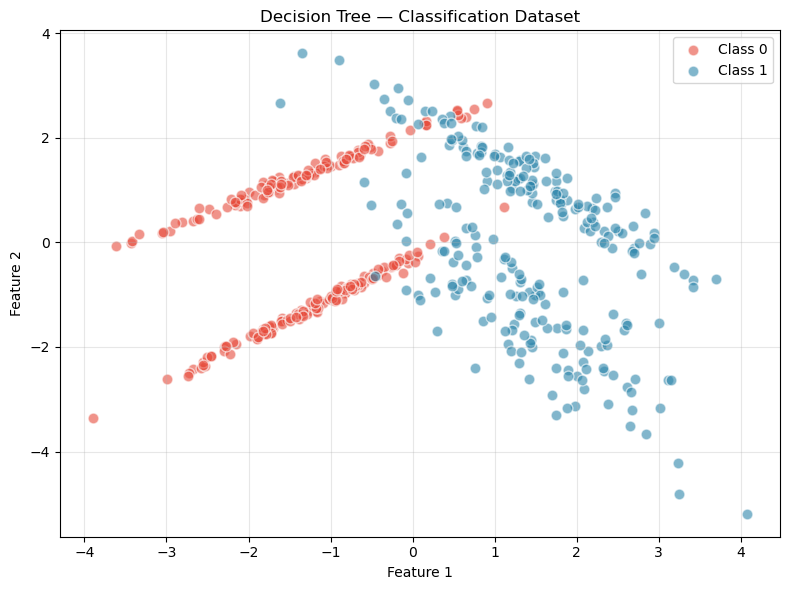

In [3]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, class_sep=1.3, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Dataset shape : {X.shape}')
print(f'Train / Test  : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Class balance : {np.bincount(y)}')

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.6, color=COLORS['danger'],
            edgecolors='white', s=60, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.6, color=COLORS['primary'],
            edgecolors='white', s=60, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Decision Tree — Classification Dataset')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Fit a Decision Tree & Visualize Its Structure

Tree depth        : 3
Number of leaves  : 7
Test Accuracy     : 0.9500


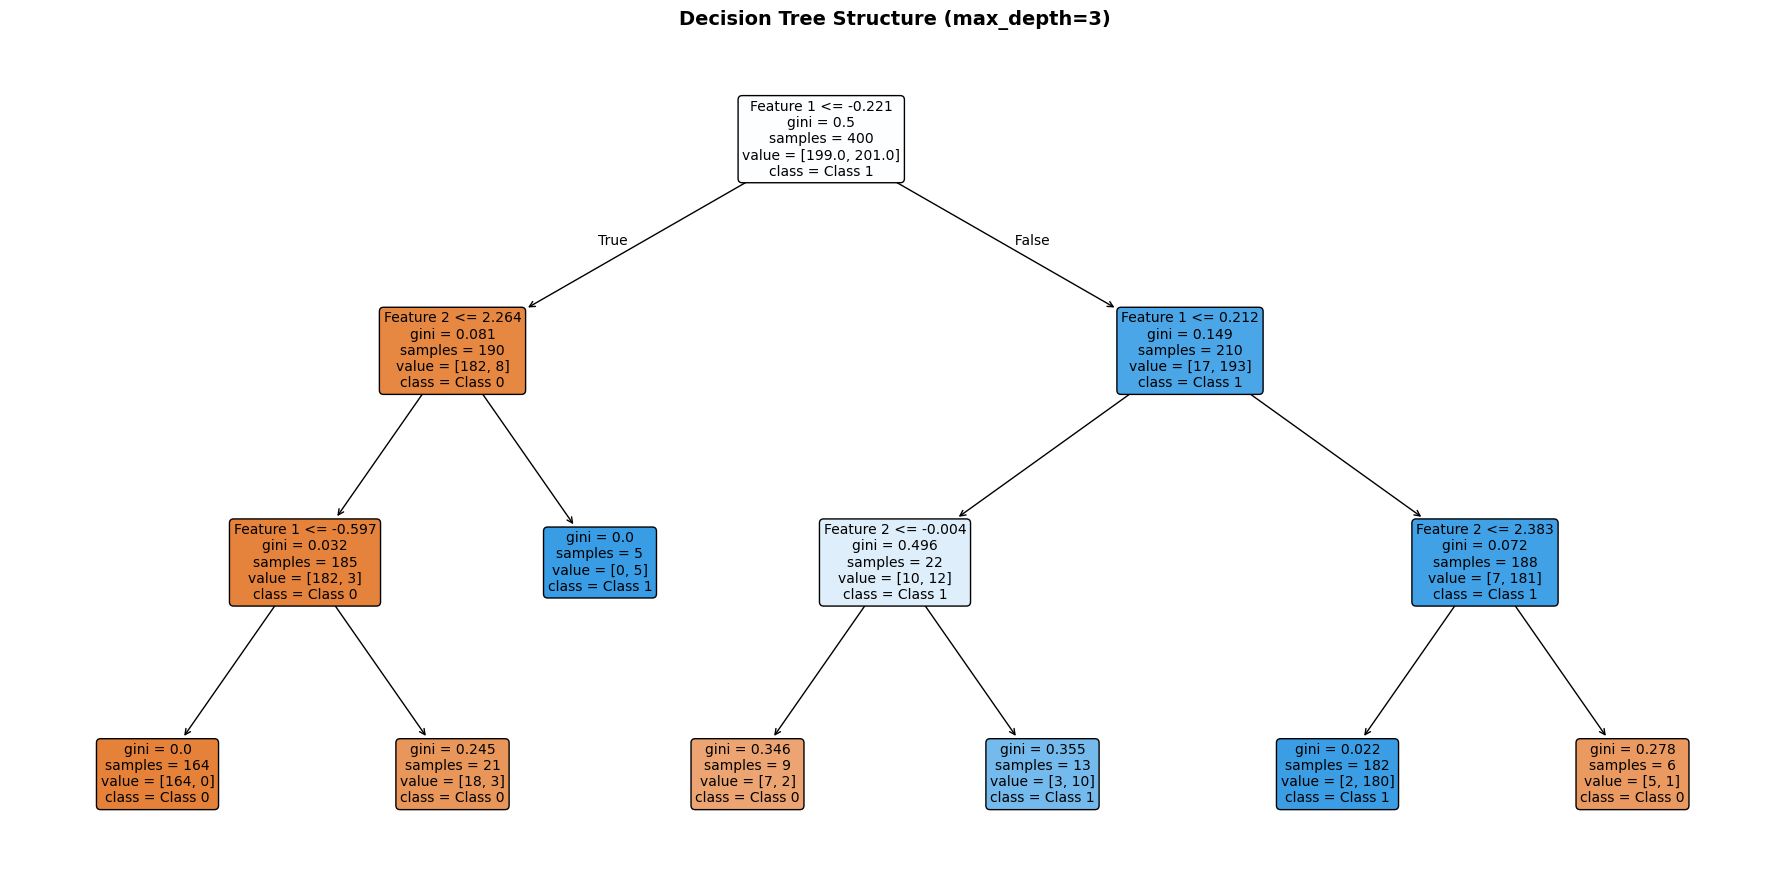

In [4]:
tree = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

print(f'Tree depth        : {tree.get_depth()}')
print(f'Number of leaves  : {tree.get_n_leaves()}')
print(f'Test Accuracy     : {accuracy_score(y_test, y_pred):.4f}')

plt.figure(figsize=(18, 9))
plot_tree(tree, feature_names=['Feature 1','Feature 2'],
          class_names=['Class 0','Class 1'], filled=True,
          rounded=True, fontsize=10)
plt.title('Decision Tree Structure (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Decision Boundary Visualization

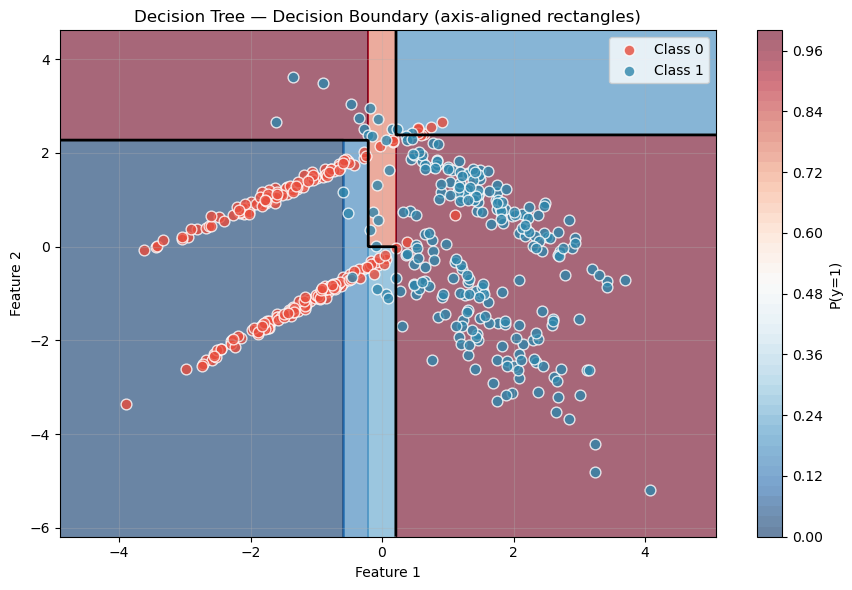

Notice: Decision Tree boundaries are always axis-aligned
(horizontal/vertical splits), creating a "staircase" pattern.


In [5]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = tree.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'], edgecolors='white',
            s=60, alpha=0.8, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'], edgecolors='white',
            s=60, alpha=0.8, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Decision Tree — Decision Boundary (axis-aligned rectangles)')
plt.legend()
plt.tight_layout()
plt.show()

print('Notice: Decision Tree boundaries are always axis-aligned')
print('(horizontal/vertical splits), creating a "staircase" pattern.')

## 6. Overfitting — Effect of max_depth (Bias-Variance Tradeoff)

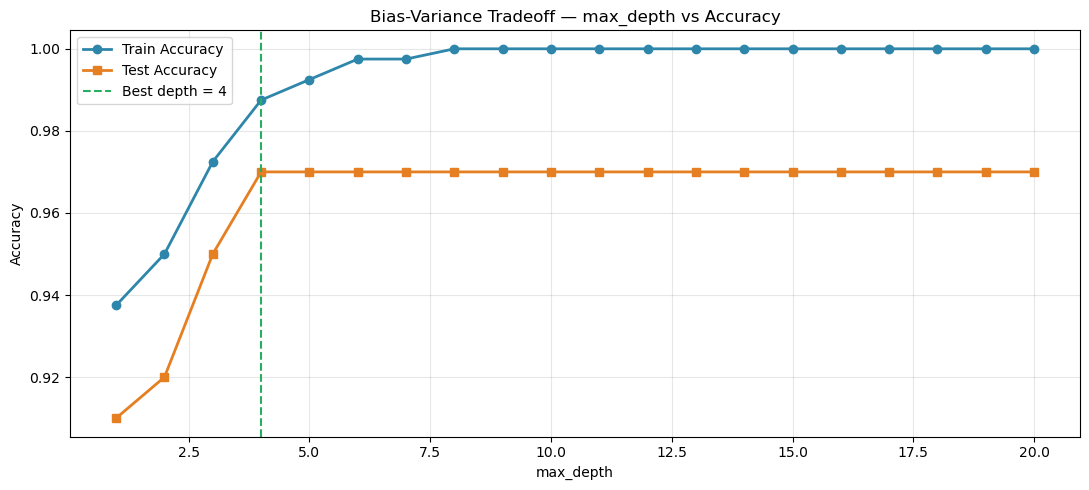

Shallow tree  (low depth)  -> High bias, underfitting
Deep tree     (high depth) -> High variance, overfitting (memorizes train set)
Best depth by test accuracy: 4


In [6]:
depths       = range(1, 21)
train_accs   = []
test_accs    = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append( accuracy_score(y_test,  t.predict(X_test)))

best_depth = list(depths)[np.argmax(test_accs)]

plt.figure(figsize=(11, 5))
plt.plot(depths, train_accs, 'o-', color=COLORS['primary'], linewidth=2, label='Train Accuracy')
plt.plot(depths, test_accs,  's-', color=COLORS['secondary'], linewidth=2, label='Test Accuracy')
plt.axvline(best_depth, color=COLORS['success'], linestyle='--',
            linewidth=1.5, label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff — max_depth vs Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print('Shallow tree  (low depth)  -> High bias, underfitting')
print('Deep tree     (high depth) -> High variance, overfitting (memorizes train set)')
print(f'Best depth by test accuracy: {best_depth}')

## 7. Comparing Different Tree Depths Visually

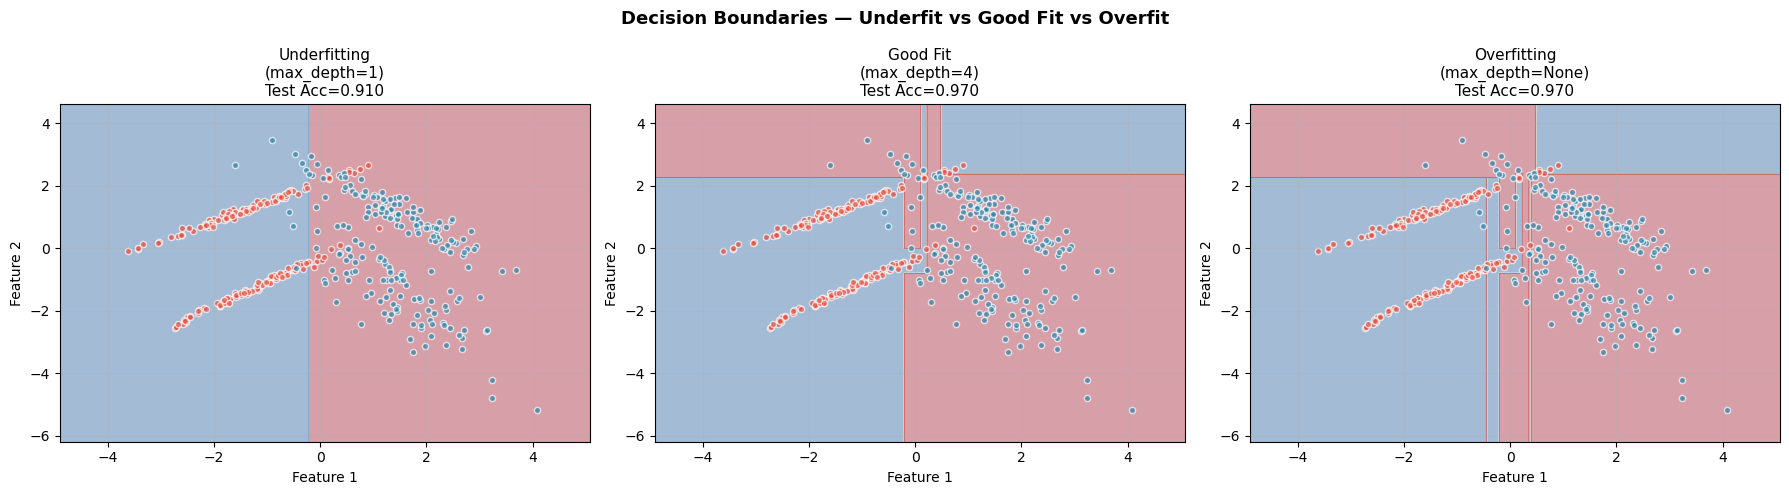

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
depths_show = [1, 4, None]   # None = fully grown (overfit)
titles      = ['Underfitting\n(max_depth=1)', 'Good Fit\n(max_depth=4)', 'Overfitting\n(max_depth=None)']

for ax, depth, title in zip(axes, depths_show, titles):
    t = DecisionTreeClassifier(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    Z = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               color=COLORS['danger'], s=20, alpha=0.7, edgecolors='white')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               color=COLORS['primary'], s=20, alpha=0.7, edgecolors='white')

    test_acc = accuracy_score(y_test, t.predict(X_test))
    ax.set_title(f'{title}\nTest Acc={test_acc:.3f}', fontsize=11)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('Decision Boundaries — Underfit vs Good Fit vs Overfit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Pruning with ccp_alpha (Cost Complexity Pruning)

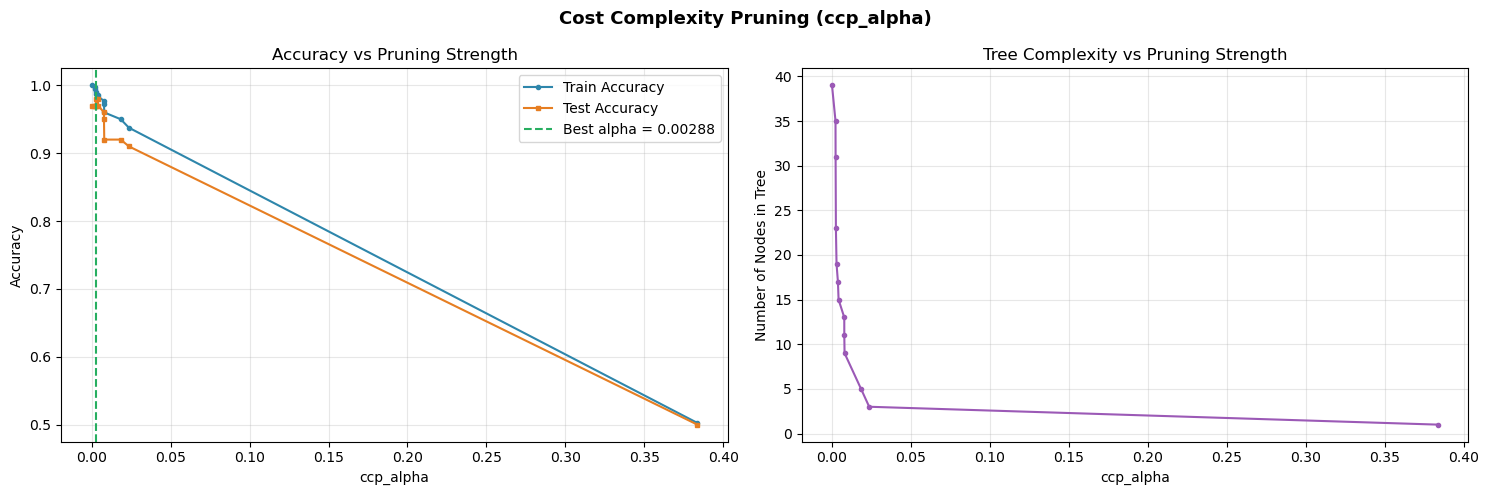

Best alpha           : 0.002878
Pruned tree depth    : 5
Pruned tree accuracy : 0.9800


NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [8]:
full_tree = DecisionTreeClassifier(random_state=42)
path      = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

train_scores = []
test_scores  = []
node_counts  = []

for alpha in ccp_alphas:
    t = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    t.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, t.predict(X_train)))
    test_scores.append( accuracy_score(y_test,  t.predict(X_test)))
    node_counts.append(t.tree_.node_count)

best_alpha_idx = np.argmax(test_scores)
best_alpha     = ccp_alphas[best_alpha_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(ccp_alphas, train_scores, 'o-', color=COLORS['primary'],
         markersize=3, linewidth=1.5, label='Train Accuracy')
ax1.plot(ccp_alphas, test_scores,  's-', color=COLORS['secondary'],
         markersize=3, linewidth=1.5, label='Test Accuracy')
ax1.axvline(best_alpha, color=COLORS['success'], linestyle='--',
            linewidth=1.5, label=f'Best alpha = {best_alpha:.5f}')
ax1.set_xlabel('ccp_alpha')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Pruning Strength')
ax1.legend()

ax2.plot(ccp_alphas, node_counts, 'o-', color=COLORS['tertiary'], markersize=3, linewidth=1.5)
ax2.set_xlabel('ccp_alpha')
ax2.set_ylabel('Number of Nodes in Tree')
ax2.set_title('Tree Complexity vs Pruning Strength')

plt.suptitle('Cost Complexity Pruning (ccp_alpha)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
print(f'Best alpha           : {best_alpha:.6f}')
print(f'Pruned tree depth    : {pruned_tree.get_depth()}')
print(f'Pruned tree accuracy : {accuracy_score(y_test, pruned_tree.predict(X_test)):.4f}')
print(f'Full tree accuracy   : {accuracy_score(y_test, full_tree.predict(X_test)):.4f}')

## 9. Feature Importance

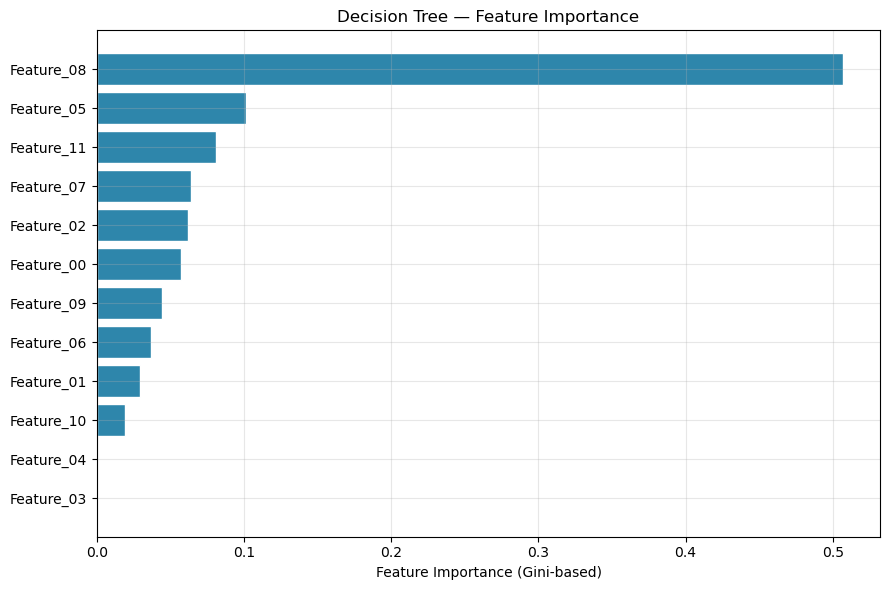

Top 5 most important features:
   Feature  Importance
Feature_08    0.506765
Feature_05    0.101499
Feature_11    0.080691
Feature_07    0.063984
Feature_02    0.061668


In [9]:
# Use a multi-feature dataset for a richer importance plot
np.random.seed(3)
X_imp, y_imp = make_classification(
    n_samples=500, n_features=12, n_informative=6, n_redundant=3,
    random_state=3
)
feat_names_imp = [f'Feature_{i:02d}' for i in range(12)]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

tree_imp = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_imp.fit(X_imp_tr, y_imp_tr)

importances = tree_imp.feature_importances_
imp_df = pd.DataFrame({
    'Feature':    feat_names_imp,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'], color=COLORS['primary'], edgecolor='white')
plt.xlabel('Feature Importance (Gini-based)')
plt.title('Decision Tree — Feature Importance')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

## 10. Decision Tree Regressor

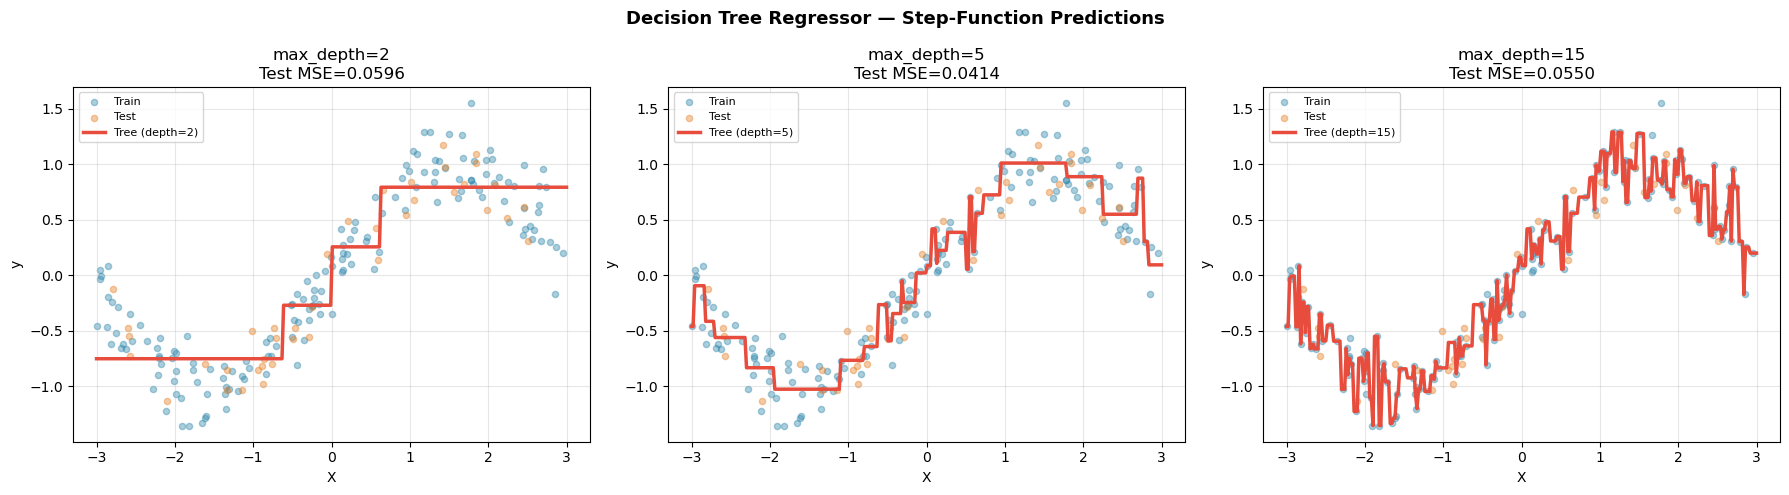

Notice: Tree regressors predict step functions (piecewise constants),
not smooth curves like Linear/Polynomial Regression.


In [10]:
np.random.seed(7)
X_r = np.sort(np.random.uniform(-3, 3, 200)).reshape(-1, 1)
y_r = np.sin(X_r).ravel() + np.random.randn(200) * 0.2

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
depths_r = [2, 5, 15]
X_plot   = np.linspace(-3, 3, 300).reshape(-1, 1)

for ax, d in zip(axes, depths_r):
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(X_r_tr, y_r_tr)
    y_plot = reg.predict(X_plot)
    test_mse = mean_squared_error(y_r_te, reg.predict(X_r_te))

    ax.scatter(X_r_tr, y_r_tr, alpha=0.4, s=20, color=COLORS['primary'], label='Train')
    ax.scatter(X_r_te, y_r_te, alpha=0.4, s=20, color=COLORS['secondary'], label='Test')
    ax.plot(X_plot, y_plot, color=COLORS['danger'], linewidth=2.5, label=f'Tree (depth={d})')
    ax.set_title(f'max_depth={d}\nTest MSE={test_mse:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('Decision Tree Regressor — Step-Function Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: Tree regressors predict step functions (piecewise constants),')
print('not smooth curves like Linear/Polynomial Regression.')

## 11. Real-World Offline-Safe Dataset — Loan Approval Prediction

In [11]:
np.random.seed(11)
n_loan = 900

Income       = np.random.uniform(15000, 150000, n_loan)
LoanAmount   = np.random.uniform(5000, 80000, n_loan)
CreditScore  = np.random.uniform(300, 850, n_loan)
LoanTerm     = np.random.choice([12, 24, 36, 48, 60], n_loan).astype(float)
Age          = np.random.randint(21, 70, n_loan).astype(float)
ExistingDebt = np.random.uniform(0, 50000, n_loan)
YearsEmploy  = np.random.uniform(0, 35, n_loan)

feat_names_loan = ['Income','LoanAmount','CreditScore','LoanTerm',
                    'Age','ExistingDebt','YearsEmploy']
X_loan = np.column_stack([Income, LoanAmount, CreditScore, LoanTerm,
                           Age, ExistingDebt, YearsEmploy])

# Realistic approval logic + noise
debt_to_income = ExistingDebt / (Income + 1)
log_odds = (-2 + 0.00003*Income - 0.00002*LoanAmount + 0.01*CreditScore
            - 3*debt_to_income + 0.05*YearsEmploy - 0.01*Age)
prob_approve = 1 / (1 + np.exp(-log_odds))
y_loan = (prob_approve > np.random.uniform(0, 1, n_loan)).astype(int)

print(f'Dataset shape : {X_loan.shape}')
print(f'Class balance : {np.bincount(y_loan)}  (0=Rejected, 1=Approved)')

X_loan_tr, X_loan_te, y_loan_tr, y_loan_te = train_test_split(
    X_loan, y_loan, test_size=0.2, random_state=42, stratify=y_loan
)

# Tune max_depth with GridSearchCV
param_grid = {'max_depth': range(2, 15), 'min_samples_leaf': [1, 5, 10, 20]}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
grid.fit(X_loan_tr, y_loan_tr)

best_tree = grid.best_estimator_
loan_pred = best_tree.predict(X_loan_te)
loan_prob = best_tree.predict_proba(X_loan_te)[:, 1]

print(f'\nBest params       : {grid.best_params_}')
print(f'Test Accuracy     : {accuracy_score(y_loan_te, loan_pred):.4f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_loan_te, loan_prob):.4f}')
print(f'Test F1 Score     : {f1_score(y_loan_te, loan_pred):.4f}')

Dataset shape : (900, 7)
Class balance : [ 82 818]  (0=Rejected, 1=Approved)

Best params       : {'max_depth': 4, 'min_samples_leaf': 20}
Test Accuracy     : 0.9056
Test ROC-AUC      : 0.9223
Test F1 Score     : 0.9493


## 12. Model Evaluation — Loan Approval

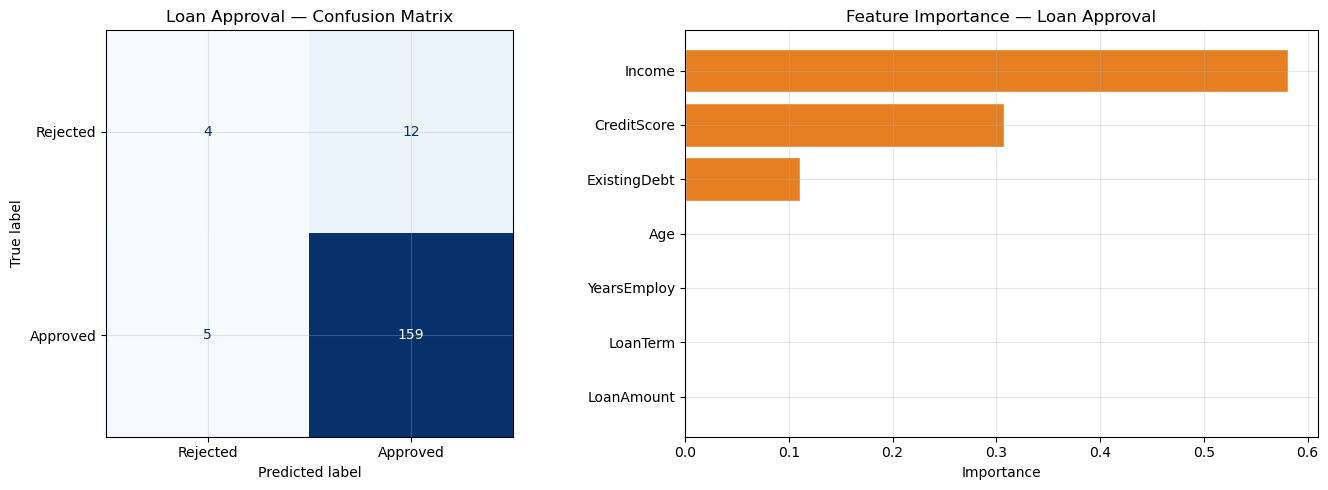

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.44      0.25      0.32        16
    Approved       0.93      0.97      0.95       164

    accuracy                           0.91       180
   macro avg       0.69      0.61      0.63       180
weighted avg       0.89      0.91      0.89       180



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_loan = confusion_matrix(y_loan_te, loan_pred)
ConfusionMatrixDisplay(cm_loan, display_labels=['Rejected','Approved']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Loan Approval — Confusion Matrix')

imp_loan = pd.DataFrame({
    'Feature':    feat_names_loan,
    'Importance': best_tree.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(imp_loan['Feature'], imp_loan['Importance'],
             color=COLORS['secondary'], edgecolor='white')
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance — Loan Approval')

plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_loan_te, loan_pred, target_names=['Rejected','Approved']))

## 13. Final Summary & Key Takeaways

In [13]:
print('=' * 64)
print('            DECISION TREE - KEY TAKEAWAYS')
print('=' * 64)

takeaways = [
    ('Splits',           'Pick feature & threshold minimizing Gini/Entropy/MSE'),
    ('Gini vs Entropy',  'Similar results; Gini is computationally faster'),
    ('Boundaries',       'Always axis-aligned (rectangular regions)'),
    ('Overfitting',      'Deep trees memorize training data — high variance'),
    ('Underfitting',     'Shallow trees miss patterns — high bias'),
    ('Pruning',          'ccp_alpha removes weak branches post-training'),
    ('Feature scaling',  'NOT required — trees split on raw thresholds'),
    ('Feature importance','Built-in via impurity reduction at each split'),
    ('Regression trees', 'Predict step functions (piecewise constant), not smooth curves'),
    ('Interpretability', 'Highly interpretable — can be visualized and explained directly'),
    ('Weakness',         'High variance; small data changes can produce very different trees'),
    ('Remedy',           'Ensembles (Random Forest, Gradient Boosting) reduce variance'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<18}  ->  {detail}')

print('=' * 64)

            DECISION TREE - KEY TAKEAWAYS
  OK  Splits              ->  Pick feature & threshold minimizing Gini/Entropy/MSE
  OK  Gini vs Entropy     ->  Similar results; Gini is computationally faster
  OK  Boundaries          ->  Always axis-aligned (rectangular regions)
  OK  Overfitting         ->  Deep trees memorize training data — high variance
  OK  Underfitting        ->  Shallow trees miss patterns — high bias
  OK  Pruning             ->  ccp_alpha removes weak branches post-training
  OK  Feature scaling     ->  NOT required — trees split on raw thresholds
  OK  Feature importance  ->  Built-in via impurity reduction at each split
  OK  Regression trees    ->  Predict step functions (piecewise constant), not smooth curves
  OK  Interpretability    ->  Highly interpretable — can be visualized and explained directly
  OK  Weakness            ->  High variance; small data changes can produce very different trees
  OK  Remedy              ->  Ensembles (Random Forest, Gradient

---
## Practice Exercises

1. **Compare criterion='gini' vs 'entropy'** on the same dataset — do results differ meaningfully?
2. **Tune min_samples_split and min_samples_leaf** with GridSearchCV alongside max_depth.
3. **Visualize a regression tree structure** using plot_tree on the sine-wave dataset.
4. **Compare a single Decision Tree vs a Random Forest** on the loan dataset — observe the accuracy and stability difference.
5. **Implement Gini impurity calculation from scratch** and verify it matches sklearn's internal computation.
6. **Export tree rules as text** using `export_text` from sklearn.tree and interpret the logic.

---
*Notebook created for the ML Repository — Decision Tree module.*